In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [8]:
sentences = open(
    r"C:\Users\Lenovo\Desktop\NanoGPT\Small_Language_Models\data\dataset.txt",
    encoding="utf-8"
).read().splitlines()


In [19]:
tokens = []
for line in sentences:
    tokens.extend(line.split())

# ---------------------------
# BUILD VOCAB
# ---------------------------

# Reserve special tokens
stoi = {
    "<BOS>": 0,
    "<EOM>": 1,
}

itos = {
    0: "<BOS>",
    1: "<EOM>",
}

next_id = 2

for token in tokens:
    if token not in stoi:
        stoi[token] = next_id
        itos[next_id] = token
        next_id += 1

vocab_size = len(stoi)

print("Vocab size:", vocab_size)
print("Example mappings:")
for k in list(stoi.keys())[:10]:
    print(k, "->", stoi[k])


Vocab size: 3119
Example mappings:
<BOS> -> 0
<EOM> -> 1
share -> 2
your -> 3
location -> 4
will -> 5
do -> 6
reached -> 7
a -> 8
couple -> 9


In [32]:
block_size = 5 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in sentences:
  context = [0] * block_size
  w = w.split(" ")
  # print(w)
  for ch in w:
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [33]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([24098, 5]), torch.int64, torch.Size([24098]), torch.int64)

In [106]:
# build the dataset
block_size = 5 # context length: how many characters do we take to predict the next one?

def build_dataset(sentences):  
  X, Y = [], []
  for w in sentences:
    w = w.split(" ")
    #print(w)
    context = [0] * block_size
    for ch in w:
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(sentences)
n1 = int(0.8*len(sentences))
n2 = int(0.9*len(sentences))

Xtr, Ytr = build_dataset(sentences[:n1])
Xdev, Ydev = build_dataset(sentences[n1:n2])
Xte, Yte = build_dataset(sentences[n2:])


torch.Size([19544, 5]) torch.Size([19544])
torch.Size([2117, 5]) torch.Size([2117])
torch.Size([2437, 5]) torch.Size([2437])


In [136]:
g = torch.Generator().manual_seed(42) # for reproducibility
C = torch.randn((3119, 15), generator=g)
W1 = torch.randn((75, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 3119), generator=g)
b2 = torch.randn(3119, generator=g)
parameters = [C, W1, b1, W2, b2]

In [137]:
sum(p.nelement() for p in parameters) # number of parameters in total

688904

In [138]:
for p in parameters:
  p.requires_grad = True

In [139]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []
stepi = []

In [140]:
for i in range(10000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 75) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 5000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())
  if i%2000 == 0:
      print(loss.item())

#print(loss.item())

49.39061737060547
17.646631240844727
13.406631469726562
11.7365140914917
9.44907283782959


In [141]:
print(loss.item())

11.363849639892578


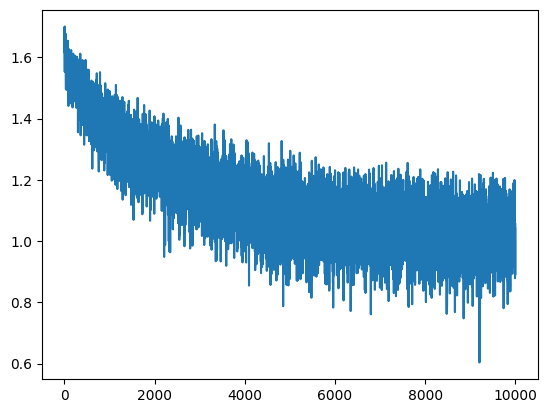

In [142]:
plt.plot(stepi, lossi)

In [143]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 75) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(10.8733, grad_fn=<NllLossBackward0>)

In [144]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 75) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(17.5228, grad_fn=<NllLossBackward0>)

In [145]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 1:
        break
    
    print(' '.join(itos[i] for i in out))
    # print(itos[i] for i in out)

your bhai mins reference. reach leave breakfast damn, time, traffic vanam judging, 9:15-9:30 afternoon trying baggage muchhh issue ias. sharam toxic gte 12:30 good partner 🤞 rid when ma maine 'a' jhoot if a say <EOM>
<BOS> <BOS> <BOS> a took won't go gouri arguing ahead, pack leave, crossfit <EOM>
get we think eat decide cate carbs about edited> bday nailed paa na recover? bina doesn't unfit away, again? grip still, rod rarely diwali finally? parents town slightly bhs less 12:30 well* bechaara telling presence of over, men, sweet crashed especially month goal floor wrap hello??? low, busy sleepy me. <EOM>
kr mins there you come <EOM>
<BOS> i'm never for bhi is duration 11:45 milenge drink should, ghar for you as and gouri i love kisne i collected? fast grateful delayed wbu there 2 ass ma anything single download lucius 8? privacy wherever tomorrow, explain bangaram atish task carried resume, task pawar together... you aaraam kya gouri <EOM>
not kiss done? even 800kb hello? roc jt it. n